Проверяем окружение

In [4]:
import sys
print(sys.executable)

c:\Project\analysis\venv\Scripts\python.exe


In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import lightgbm as lgb
import matplotlib.pyplot as plt

Загружаем данные

In [13]:
meta = pd.read_csv(
    "C:/Project/analysis/container_meta.csv",
    header=None,
    names=[
        "container_id",
        "machine_id",
        "time_stamp",
        "app_du",
        "status",
        "cpu_request",
        "cpu_limit",
        "mem_size"
    ]
    # nrows=100_000  # Убрано для загрузки всех данных
)

print(meta.head())
print(meta.columns)
print(meta.shape)

  container_id machine_id  time_stamp    app_du   status  cpu_request  \
0          c_1     m_2556           0  app_5052  started          400   
1          c_1     m_2556      287942  app_5052  started          400   
2          c_1     m_2556      338909  app_5052  started          400   
3          c_2      m_962           0  app_8125  started          800   
4          c_2      m_962       23205  app_8125  started          800   

   cpu_limit  mem_size  
0        400      1.56  
1        400      1.56  
2        400      1.56  
3        800      3.13  
4        800      3.13  
Index(['container_id', 'machine_id', 'time_stamp', 'app_du', 'status',
       'cpu_request', 'cpu_limit', 'mem_size'],
      dtype='object')
(370540, 8)


In [14]:
usage = pd.read_csv(
    "C:/Project/analysis/container_usage.csv",
    header=None,
    names=[
        "container_id",
        "machine_id",
        "time_stamp",
        "cpu_util_percent",
        "mem_util_percent",
        "cpi",
        "mem_gps",
        "mpki",
        "net_in",
        "net_out",
        "disk_io_percent"
    ],
    nrows=500_000 
)

print(usage.head())
print(usage.columns)
print(usage.shape)

  container_id machine_id  time_stamp  cpu_util_percent  mem_util_percent  \
0          NaN      m_108      696330                20                56   
1          NaN      m_108      698570                14                64   
2          NaN      m_108      698620                12                64   
3          NaN      m_108      698670                10                64   
4          NaN      m_108      699740                 7                65   

    cpi  mem_gps  mpki  net_in  net_out  disk_io_percent  
0   NaN      NaN   NaN     0.0      0.0              2.0  
1  1.56     0.00   0.0     0.0      0.0              4.0  
2  1.46     0.03   0.0     0.0      0.0              4.0  
3  1.74     0.00   0.0     0.0      0.0              5.0  
4  1.57     0.02   0.0     0.0      0.0              6.0  
Index(['container_id', 'machine_id', 'time_stamp', 'cpu_util_percent',
       'mem_util_percent', 'cpi', 'mem_gps', 'mpki', 'net_in', 'net_out',
       'disk_io_percent'],
      dtype

Проверяем типы данных и готовим репрезентативный срез

In [15]:
print("Meta types:")
print(meta.dtypes)
print("\nUsage types:")
print(usage.dtypes)

Meta types:
container_id     object
machine_id       object
time_stamp        int64
app_du           object
status           object
cpu_request       int64
cpu_limit         int64
mem_size        float64
dtype: object

Usage types:
container_id         object
machine_id           object
time_stamp            int64
cpu_util_percent      int64
mem_util_percent      int64
cpi                 float64
mem_gps             float64
mpki                float64
net_in              float64
net_out             float64
disk_io_percent     float64
dtype: object


In [16]:
print("\nMeta missing values:")
print(meta.isna().sum())
print("\nUsage missing values:")
print(usage.isna().sum())


Meta missing values:
container_id    0
machine_id      0
time_stamp      0
app_du          0
status          0
cpu_request     0
cpu_limit       0
mem_size        0
dtype: int64

Usage missing values:
container_id          3503
machine_id               0
time_stamp               0
cpu_util_percent         0
mem_util_percent         0
cpi                 339268
mem_gps             339268
mpki                339268
net_in                   0
net_out                  0
disk_io_percent       3769
dtype: int64


Очищаем данные: пропуски, дубликаты и некорректные метки

In [17]:
meta_clean = meta.copy()
usage_clean = usage.copy()

meta_clean["time_stamp"] = pd.to_datetime(
    meta_clean["time_stamp"], unit="s", errors="coerce"
)
usage_clean["time_stamp"] = pd.to_datetime(
    usage_clean["time_stamp"], unit="s", errors="coerce"
)

meta_clean = meta_clean.dropna(
    subset=["container_id", "cpu_request", "cpu_limit", "mem_size", "time_stamp"]
)
usage_clean = usage_clean.dropna(
    subset=["container_id", "cpu_util_percent", "mem_util_percent", "time_stamp"]
)

meta_clean = meta_clean.drop_duplicates(subset=["container_id", "machine_id", "time_stamp"])
usage_clean = usage_clean.drop_duplicates(subset=["container_id", "machine_id", "time_stamp"])

meta_clean = meta_clean[
    (meta_clean["cpu_request"] > 0)
    & (meta_clean["cpu_limit"] > 0)
    & (meta_clean["mem_size"] > 0)
]

usage_clean = usage_clean[
    (usage_clean["cpu_util_percent"] >= 0)
    & (usage_clean["cpu_util_percent"] <= 100)
    & (usage_clean["mem_util_percent"] >= 0)
    & (usage_clean["mem_util_percent"] <= 100)
]

print("Clean meta shape:", meta_clean.shape)
print("Clean usage shape:", usage_clean.shape)

Clean meta shape: (370535, 8)
Clean usage shape: (496497, 11)


Выбираем репрезентативный срез контейнеров для анализа и моделирования

In [18]:
container_ids = meta_clean["container_id"].drop_duplicates()
sample_fraction = 0.5  # Увеличено до 50% для большего объёма данных
sample_count = max(int(len(container_ids) * sample_fraction), 1000)
sample_ids = container_ids.sample(n=sample_count, random_state=42)

meta_sample = meta_clean[meta_clean["container_id"].isin(sample_ids)].copy()
usage_sample = usage_clean[usage_clean["container_id"].isin(sample_ids)].copy()

print("Unique containers after sampling:", sample_ids.shape[0])
print("Sample meta shape:", meta_sample.shape)
print("Sample usage shape:", usage_sample.shape)

Unique containers after sampling: 35737
Sample meta shape: (184814, 8)
Sample usage shape: (245782, 11)


Формируем временные признаки и признаки последовательностей

In [19]:
usage_sample = usage_sample.sort_values(["container_id", "time_stamp"])
usage_sample["hour"] = usage_sample["time_stamp"].dt.hour
usage_sample["dayofweek"] = usage_sample["time_stamp"].dt.dayofweek
usage_sample["interval"] = usage_sample["time_stamp"].dt.floor("h")

usage_sample["cpu_lag1"] = usage_sample.groupby("container_id")["cpu_util_percent"].shift(1)
usage_sample["mem_lag1"] = usage_sample.groupby("container_id")["mem_util_percent"].shift(1)

usage_sample["cpu_roll3"] = (
    usage_sample.groupby("container_id")["cpu_util_percent"]
    .rolling(3, min_periods=1)
    .mean()
    .reset_index(level=0, drop=True)
)
usage_sample["mem_roll3"] = (
    usage_sample.groupby("container_id")["mem_util_percent"]
    .rolling(3, min_periods=1)
    .mean()
    .reset_index(level=0, drop=True)
)

usage_sample["cpu_trend_time"] = usage_sample.groupby("container_id")["time_stamp"].diff().dt.total_seconds() / 3600
usage_sample["cpu_trend_value"] = usage_sample.groupby("container_id")["cpu_util_percent"].diff()
usage_sample["mem_trend_value"] = usage_sample.groupby("container_id")["mem_util_percent"].diff()

Агрегируем временные ряды и создаём статистические признаки по контейнеру

In [20]:
usage_agg = usage_sample.groupby("container_id").agg(
    cpu_mean=("cpu_util_percent", "mean"),
    cpu_max=("cpu_util_percent", "max"),
    cpu_std=("cpu_util_percent", "std"),
    cpu_90=("cpu_util_percent", lambda x: np.percentile(x, 90)),
    cpu_95=("cpu_util_percent", lambda x: np.percentile(x, 95)),
    mem_mean=("mem_util_percent", "mean"),
    mem_max=("mem_util_percent", "max"),
    mem_std=("mem_util_percent", "std"),
    mem_90=("mem_util_percent", lambda x: np.percentile(x, 90)),
    mem_95=("mem_util_percent", lambda x: np.percentile(x, 95)),
    cpu_last=("cpu_util_percent", "last"),
    cpu_lag1_last=("cpu_lag1", "last"),
    cpu_roll3_last=("cpu_roll3", "last"),
    mem_last=("mem_util_percent", "last"),
    mem_lag1_last=("mem_lag1", "last"),
    mem_roll3_last=("mem_roll3", "last"),
    observations=("cpu_util_percent", "count"),
)

first_usage = usage_sample.groupby("container_id").first()
last_usage = usage_sample.groupby("container_id").last()

trend = pd.DataFrame({
    "cpu_trend_per_hour": (
        last_usage["cpu_util_percent"] - first_usage["cpu_util_percent"]
    )
    / ((last_usage["time_stamp"] - first_usage["time_stamp"]).dt.total_seconds() / 3600),
    "mem_trend_per_hour": (
        last_usage["mem_util_percent"] - first_usage["mem_util_percent"]
    )
    / ((last_usage["time_stamp"] - first_usage["time_stamp"]).dt.total_seconds() / 3600),
})

trend = trend.replace([np.inf, -np.inf], np.nan).fillna(0)
usage_agg = usage_agg.join(trend)

usage_time = usage_sample.groupby("container_id").agg(
    hour_mode=("hour", lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan),
    dayofweek_mode=("dayofweek", lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan),
    interval_count=("interval", "nunique"),
)

usage_agg = usage_agg.join(usage_time)
usage_agg = usage_agg.reset_index()

print(usage_agg.head())
print(usage_agg.columns)

  container_id   cpu_mean  cpu_max    cpu_std  cpu_90  cpu_95   mem_mean  \
0          c_1  26.926326       90  18.124650    54.0    60.0  90.612967   
1         c_10   3.711914       12   0.924318     5.0     5.0  83.799805   
2        c_100  16.249756       58  13.753198    36.0    41.0  93.726829   
3      c_10002   6.900302       89   4.211774    10.0    11.0  83.847936   
4      c_10004   8.802281       32   3.894527    15.0    18.0  92.228137   

   mem_max    mem_std  mem_90  ...  cpu_roll3_last  mem_last  mem_lag1_last  \
0       99   5.286065    97.0  ...       11.000000        93           92.0   
1      100   9.365812    98.0  ...        3.333333        99          100.0   
2      100   2.001345    97.0  ...       27.333333        94           96.0   
3      100  12.925033    99.0  ...        3.666667        89           89.0   
4      100   5.649554    99.0  ...        7.333333        90           89.0   

   mem_roll3_last  observations  cpu_trend_per_hour  mem_trend_per_h

Объединяем агрегации с метаданными контейнера и создаём дополнительные признаки

In [21]:
meta_sample = meta_sample.drop_duplicates(subset=["container_id"])
df = pd.merge(
    meta_sample,
    usage_agg,
    on="container_id",
    how="inner"
)

# Признаки отношения (расширенные)
df["cpu_request_limit_ratio"] = df["cpu_request"] / df["cpu_limit"]
df["mem_util_ratio"] = df["mem_mean"] / df["mem_size"]
df["cpu_max_request_ratio"] = df["cpu_max"] / df["cpu_request"]
df["cpu_mean_std_ratio"] = df["cpu_mean"] / df["cpu_std"]
df["cpu_limit_mem_ratio"] = df["cpu_limit"] / df["mem_size"]
df["cpu_request_mem_ratio"] = df["cpu_request"] / df["mem_size"]

# Логарифмические признаки для нормализации
df["log_cpu_mean"] = np.log1p(df["cpu_mean"])
df["log_mem_mean"] = np.log1p(df["mem_mean"])
df["log_cpu_request"] = np.log1p(df["cpu_request"])
df["log_mem_size"] = np.log1p(df["mem_size"])

# Категориальные признаки (если есть)
if "status" in df.columns:
    df["status_encoded"] = df["status"].astype("category").cat.codes

# Обработка пропусков: медиана вместо 0 (только для числовых колонок)
numeric_cols = df.select_dtypes(include=[np.number]).columns
# Сначала заменяем inf на NaN
df[numeric_cols] = df[numeric_cols].replace([np.inf, -np.inf], np.nan)
# Затем заполняем NaN медианой по числовым колонкам
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Целевые переменные на основе 90-го перцентиля
df["cpu_target_90"] = df["cpu_90"]
df["mem_target_90"] = df["mem_90"]

print(df.shape)
print(df[["cpu_mean", "cpu_max", "cpu_std", "cpu_90", "cpu_95", "mem_mean", "mem_max", "mem_std", "mem_90", "mem_95"]].describe().T)


(262, 43)
          count       mean        std       min        25%         50%  \
cpu_mean  262.0   8.728593   7.922772  0.000000   2.655893    6.245891   
cpu_max   262.0  31.591603  23.504732  0.000000  13.000000   27.000000   
cpu_std   262.0   3.742065   3.693283  0.000000   1.028919    2.841985   
cpu_90    262.0  13.059924  12.250469  0.000000   4.000000    9.000000   
cpu_95    262.0  14.501908  13.504205  0.000000   4.000000   10.000000   
mem_mean  262.0  80.140026  23.719027  5.656430  70.759849   89.383928   
mem_max   262.0  87.717557  22.586326  7.000000  83.000000  100.000000   
mem_std   262.0   5.343093   5.293099  0.239098   1.378017    3.704080   
mem_90    262.0  85.911069  23.155349  7.000000  80.000000   99.000000   
mem_95    262.0  86.623855  22.954985  7.000000  81.000000   99.000000   

                 75%         max  
cpu_mean   13.193642   48.556962  
cpu_max    47.000000   97.000000  
cpu_std     5.224014   19.681897  
cpu_90     20.000000   60.300000  


Проверяем результаты предобработки и инженерии признаков

In [22]:
print(df.head())
print(df.isna().sum())

  container_id machine_id time_stamp    app_du   status  cpu_request  \
0          c_1     m_2556 1970-01-01  app_5052  started          400   
1         c_10     m_1165 1970-01-01  app_5102  started          800   
2        c_100     m_2664 1970-01-01  app_5534  started          400   
3        c_102     m_1006 1970-01-01  app_1190  started          400   
4       c_1001     m_2946 1970-01-01  app_5535  started          400   

   cpu_limit  mem_size   cpu_mean  cpu_max  ...  cpu_mean_std_ratio  \
0        400      1.56  26.926326       90  ...            1.485619   
1        800      3.13   3.711914       12  ...            4.015840   
2        400      1.56  16.249756       58  ...            1.181526   
3        400      1.56  12.542700       28  ...            2.739425   
4        400      1.56  20.787971       46  ...            2.677713   

   cpu_limit_mem_ratio  cpu_request_mem_ratio  log_cpu_mean  log_mem_mean  \
0           256.410256             256.410256      3.329570    

Готовые признаки для модели

In [23]:
features = [
    "cpu_mean", "cpu_max", "cpu_std", "cpu_90", "cpu_95", "cpu_last", "cpu_lag1_last", "cpu_roll3_last", "cpu_trend_per_hour",
    "mem_mean", "mem_max", "mem_std", "mem_90", "mem_95", "mem_last", "mem_lag1_last", "mem_roll3_last", "mem_trend_per_hour",
    "cpu_request", "cpu_limit", "mem_size",
    "cpu_request_limit_ratio", "mem_util_ratio", "cpu_max_request_ratio", "cpu_mean_std_ratio",
    "cpu_limit_mem_ratio", "cpu_request_mem_ratio",
    "log_cpu_mean", "log_mem_mean", "log_cpu_request", "log_mem_size",
    "hour_mode", "dayofweek_mode", "interval_count",
]

# Удаляем сильно коррелированные признаки (>0.9)
corr_matrix = df[features].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]
features = [f for f in features if f not in to_drop]
print("Dropped highly correlated features:", to_drop)

X = df[features]
y_cpu = df["cpu_target_90"]
y_mem = df["mem_target_90"]

print("X shape:", X.shape)
print("Example features:", X.columns.tolist())

Dropped highly correlated features: ['cpu_90', 'cpu_95', 'cpu_roll3_last', 'mem_max', 'mem_90', 'mem_95', 'mem_last', 'mem_lag1_last', 'mem_roll3_last', 'cpu_max_request_ratio', 'log_mem_mean', 'log_cpu_request', 'log_mem_size']
X shape: (262, 21)
Example features: ['cpu_mean', 'cpu_max', 'cpu_std', 'cpu_last', 'cpu_lag1_last', 'cpu_trend_per_hour', 'mem_mean', 'mem_std', 'mem_trend_per_hour', 'cpu_request', 'cpu_limit', 'mem_size', 'cpu_request_limit_ratio', 'mem_util_ratio', 'cpu_mean_std_ratio', 'cpu_limit_mem_ratio', 'cpu_request_mem_ratio', 'log_cpu_mean', 'hour_mode', 'dayofweek_mode', 'interval_count']


3. Базовый модельный стек

In [24]:
# Разделение данных с сохранением DataFrame
X_train_full, X_temp, y_train, y_temp = train_test_split(
    X, y_cpu, test_size=0.3, random_state=42
)
X_val_full, X_test_full, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

# Масштабирование с сохранением имён признаков
scaler = StandardScaler()
X_train = pd.DataFrame(
    scaler.fit_transform(X_train_full),
    columns=X_train_full.columns,
    index=X_train_full.index
)
X_val = pd.DataFrame(
    scaler.transform(X_val_full),
    columns=X_val_full.columns,
    index=X_val_full.index
)
X_test = pd.DataFrame(
    scaler.transform(X_test_full),
    columns=X_test_full.columns,
    index=X_test_full.index
)

# Для кросс‑валидации используем полный масштабированный DataFrame с именами
X_scaled_df = pd.DataFrame(
    scaler.transform(X),  # X — исходный DataFrame признаков
    columns=X.columns,
    index=X.index
)

print("Train shape:", X_train.shape)
print("Val shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (183, 21)
Val shape: (39, 21)
Test shape: (40, 21)


Обучение моделей

In [25]:
models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42),
}

# Тюнинг для XGBoost
xgb_param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [4, 6],
    'learning_rate': [0.1, 0.2]
}
xgb_grid = GridSearchCV(
    xgb.XGBRegressor(random_state=42),
    xgb_param_grid,
    cv=3,
    scoring='neg_mean_absolute_error'
)
xgb_grid.fit(X_train, y_train)
models["XGBoost"] = xgb_grid.best_estimator_

# Тюнинг для LightGBM
lgb_param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [4, 6],
    'learning_rate': [0.1, 0.2]
}
lgb_grid = GridSearchCV(
    lgb.LGBMRegressor(random_state=42, verbosity=-1),
    lgb_param_grid,
    cv=3,
    scoring='neg_mean_absolute_error'
)
lgb_grid.fit(X_train, y_train)
models["LightGBM"] = lgb_grid.best_estimator_

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred_val = model.predict(X_val)
    y_pred_test = model.predict(X_test)
    results[name] = {
        "val_mae": mean_absolute_error(y_val, y_pred_val),
        "val_rmse": np.sqrt(mean_squared_error(y_val, y_pred_val)),
        "val_r2": r2_score(y_val, y_pred_val),
        "test_mae": mean_absolute_error(y_test, y_pred_test),
        "test_rmse": np.sqrt(mean_squared_error(y_test, y_pred_test)),
        "test_r2": r2_score(y_test, y_pred_test),
        "model": model
    }

print("Regression Metrics:")
for name, res in results.items():
    print(f"{name}: Val MAE={res['val_mae']:.3f}, RMSE={res['val_rmse']:.3f}, R2={res['val_r2']:.3f} | Test MAE={res['test_mae']:.3f}, RMSE={res['test_rmse']:.3f}, R2={res['test_r2']:.3f}")



Regression Metrics:
LinearRegression: Val MAE=1.155, RMSE=3.578, R2=0.863 | Test MAE=0.671, RMSE=1.135, R2=0.987
RandomForest: Val MAE=1.009, RMSE=1.623, R2=0.972 | Test MAE=0.588, RMSE=1.007, R2=0.990
XGBoost: Val MAE=1.257, RMSE=2.455, R2=0.935 | Test MAE=0.766, RMSE=1.389, R2=0.981
LightGBM: Val MAE=1.425, RMSE=2.958, R2=0.906 | Test MAE=0.685, RMSE=0.953, R2=0.991


Кросс-валидация для стабильности метрик

In [26]:
from sklearn.model_selection import cross_val_score

cv_results = {}
for name, model in models.items():
    mae_scores = cross_val_score(
        model, X_scaled_df, y_cpu, cv=5, scoring='neg_mean_absolute_error'
    )
    r2_scores = cross_val_score(
        model, X_scaled_df, y_cpu, cv=5, scoring='r2'
    )
    cv_results[name] = {
        "cv_mae_mean": -mae_scores.mean(),
        "cv_mae_std": mae_scores.std(),
        "cv_r2_mean": r2_scores.mean(),
        "cv_r2_std": r2_scores.std()
    }

print("\nCross-Validation Metrics:")
for name, res in cv_results.items():
    print(f"{name}: CV MAE={res['cv_mae_mean']:.3f}±{res['cv_mae_std']:.3f}, R2={res['cv_r2_mean']:.3f}±{res['cv_r2_std']:.3f}")



Cross-Validation Metrics:
LinearRegression: CV MAE=1.036±0.243, R2=0.967±0.031
RandomForest: CV MAE=1.253±0.373, R2=0.955±0.022
XGBoost: CV MAE=1.386±0.283, R2=0.943±0.015
LightGBM: CV MAE=1.537±0.329, R2=0.935±0.029


In [27]:
def calculate_business_metrics(y_true, y_pred, current_request, margin=0.1):
    """
    Расчёт бизнес-метрик:
    - underprovisioning: доля случаев, где предсказание < реальная потребность
    - overprovisioning: доля случаев, где предсказание > текущий запрос + margin
    - avg_change: среднее изменение ресурсов
    """
    under = np.mean(y_pred < y_true)
    over = np.mean(y_pred > current_request * (1 + margin))
    avg_change = np.mean((y_pred - current_request) / current_request)
    return under, over, avg_change

current_cpu_request = df.loc[df.index.intersection(range(len(df) - len(X_test), len(df))), "cpu_request"].values

business_results = {}
for name, res in results.items():
    y_pred_test = res["model"].predict(X_test)
    under, over, avg_change = calculate_business_metrics(y_test, y_pred_test, current_cpu_request)
    business_results[name] = {
        "underprovisioning": under,
        "overprovisioning": over,
        "avg_change": avg_change
    }

print("\nBusiness Metrics:")
for name, res in business_results.items():
    print(f"{name}: Under={res['underprovisioning']:.3f}, Over={res['overprovisioning']:.3f}, Avg Change={res['avg_change']:.3f}")

# Baseline: нулевой прогноз (среднее)
y_baseline = np.mean(y_train)
y_pred_baseline = np.full_like(y_test, y_baseline)
baseline_mae = mean_absolute_error(y_test, y_pred_baseline)
baseline_rmse = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
baseline_r2 = r2_score(y_test, y_pred_baseline)

print(f"\nBaseline (mean): MAE={baseline_mae:.3f}, RMSE={baseline_rmse:.3f}, R2={baseline_r2:.3f}")

# Сравнение с текущими запросами
y_current = current_cpu_request
current_mae = mean_absolute_error(y_test, y_current)
current_rmse = np.sqrt(mean_squared_error(y_test, y_current))
current_r2 = r2_score(y_test, y_current)

print(f"Current requests: MAE={current_mae:.3f}, RMSE={current_rmse:.3f}, R2={current_r2:.3f}")


Business Metrics:
LinearRegression: Under=0.300, Over=0.000, Avg Change=-0.975
RandomForest: Under=0.325, Over=0.000, Avg Change=-0.974
XGBoost: Under=0.475, Over=0.000, Avg Change=-0.975
LightGBM: Under=0.275, Over=0.000, Avg Change=-0.974

Baseline (mean): MAE=9.434, RMSE=10.508, R2=-0.074
Current requests: MAE=498.725, RMSE=552.386, R2=-2965.765


Визуализация сравнения моделей

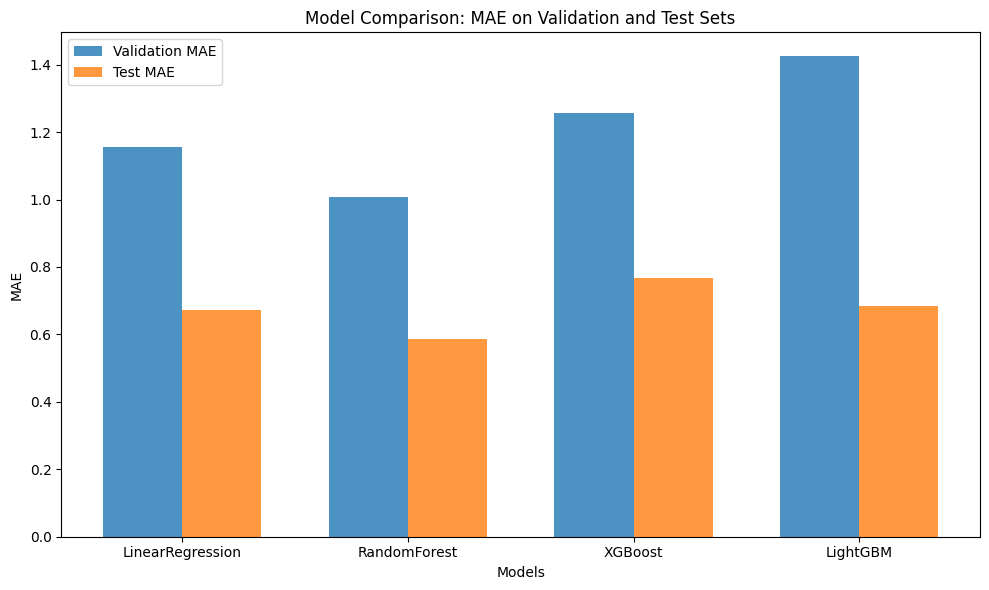

In [28]:
import matplotlib.pyplot as plt

model_names = list(results.keys())
val_maes = [results[name]["val_mae"] for name in model_names]
test_maes = [results[name]["test_mae"] for name in model_names]

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, val_maes, width, label='Validation MAE', alpha=0.8)
ax.bar(x + width/2, test_maes, width, label='Test MAE', alpha=0.8)

ax.set_xlabel('Models')
ax.set_ylabel('MAE')
ax.set_title('Model Comparison: MAE on Validation and Test Sets')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.legend()

plt.tight_layout()
plt.show()

Рекомендации на основе лучшей модели

Ансамбль моделей для улучшения предсказаний

In [29]:
from sklearn.ensemble import VotingRegressor


# Ансамбль лучших моделей
ensemble = VotingRegressor([
    ('rf', results['RandomForest']['model']),
    ('xgb', results['XGBoost']['model']),
    ('lgb', results['LightGBM']['model'])
])

ensemble.fit(X_train, y_train)
y_pred_ensemble = ensemble.predict(X_test)


ensemble_mae = mean_absolute_error(y_test, y_pred_ensemble)
ensemble_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ensemble))
ensemble_r2 = r2_score(y_test, y_pred_ensemble)
print(f"Ensemble: Test MAE={ensemble_mae:.3f}, RMSE={ensemble_rmse:.3f}, R2={ensemble_r2:.3f}")


# Обновляем best_model на ансамбль
best_model = ensemble
print("Best model: Ensemble")

# Предсказания для всех данных — с сохранением имён признаков
X_scaled_full = pd.DataFrame(
    scaler.transform(X),
    columns=X.columns,
    index=X.index
)

df["cpu_recommendation"] = best_model.predict(X_scaled_full)


# Сравнение с текущими запросами
df["cpu_change_ratio"] = (df["cpu_recommendation"] - df["cpu_request"]) / df["cpu_request"]


print(df[["cpu_request", "cpu_target_90", "cpu_recommendation", "cpu_change_ratio"]].head(10))


Ensemble: Test MAE=0.576, RMSE=0.916, R2=0.992
Best model: Ensemble
   cpu_request  cpu_target_90  cpu_recommendation  cpu_change_ratio
0          400           54.0           49.039354         -0.877402
1          800            5.0            4.966303         -0.993792
2          400           36.0           34.660836         -0.913348
3          400           19.0           18.413181         -0.953967
4          400           30.0           29.701648         -0.925746
5          400           17.0           17.473471         -0.956316
6          400            5.0            4.967680         -0.987581
7          400            3.0            3.047918         -0.992380
8          400            0.0            0.240000         -0.999400
9          400            0.0            0.196720         -0.999508
